# Imports

In [9]:
import pandas as pd
import sys
import psycopg2
import os
from pathlib import Path

# move up from analytics/analysis/ to repo root
PROJECT_ROOT = Path.cwd().resolve().parents[1]
while PROJECT_ROOT.name != "procurement_agent" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

from dotenv import load_dotenv 
from analytics.scoring import SupplierScorer, load_contract

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent


# DB Connection

In [10]:
load_dotenv() # Load environment variables from .env file

True

In [11]:
conn = psycopg2.connect(
    dbname=os.getenv('PGDATABASE'),
    user=os.getenv('PGUSER'),
    password=os.getenv('PGPASSWORD'),
    host=os.getenv('PGHOST'),
    port=os.getenv('PGPORT')
)

print("Database connection established successfully.")

Database connection established successfully.


# Load SQL View

In [12]:
query = """
SELECT * FROM vw_supplier_complete_profile
"""

df = pd.read_sql(query, conn)

df.shape

/var/folders/7r/bkznjk192kggm19g_v70_z240000gn/T/ipykernel_97311/692280052.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(89, 18)

# Initialize Scorer and Scoring Contract

In [13]:
contract = load_contract(str(PROJECT_ROOT / "analytics" / "metric_contract.yaml"))
scorer = SupplierScorer(contract)

# Run Scoring

In [14]:
result = scorer.score(df,
                      Q=6000,
                      lambda_risk=0.5,
                      top_k=25)

ranked = result.ranked
dropped = result.dropped_rows

# Inspecting Score Distributions

In [15]:
ranked[[
    "EffectiveUnitPrice",
    "RiskPenalty",
    "RiskAdjustedCost"
]].describe()

,EffectiveUnitPrice,RiskPenalty,RiskAdjustedCost
count,25.000000,25.000000,25.000000
mean,0.247586,30.344060,0.384467
std,0.322020,8.381548,0.197015
min,0.029604,15.646772,0.028421
25%,0.035262,24.512543,0.274458
50%,0.083036,30.424731,0.448303
75%,0.169396,33.882098,0.517279
max,0.902069,54.870165,0.698355


**EffectiveUnitPrice Interpretation**
This is normalized so:
- ~0.03 = cheapest supplier in product group
- ~0.90 = most expensive supplier in product grouping

**RiskPenalty Interpretation**
- Raw Risk Penalty (lower score better)

**RiskAdjustedCost Interpretation**
- Cost after incorporating risk penalty.
- LandedUnitPrice + lambda * RiskScore/RiskPenalty
Normalized score. Good spread (lower score better)

# Ranking Inspection

In [ ]:
# inspecting top suppliers

ranked[
    ["SupplierID", "CountryCode", "Product", "EffectiveUnitPrice", "RiskPenalty", "RiskAdjustedCost"]
].sort_values("RiskAdjustedCost").head(10) # only issue is USAs prominence for transistors given our current dataset. Might consider tying them to FRED data (currently BLS)

,SupplierID,CountryCode,Product,EffectiveUnitPrice,RiskPenalty,RiskAdjustedCost
0,SUP_DEU_23,DEU,microprocessors,0.767901,28.660782,0.028421
1,SUP_USA_91,USA,transistors,0.029604,22.283884,0.048694
2,SUP_DEU_25,DEU,microprocessors,0.781232,28.503835,0.060697
3,SUP_USA_90,USA,transistors,0.030992,21.591232,0.114553
4,SUP_USA_88,USA,transistors,0.030361,24.512543,0.136727
5,SUP_SGP_71,SGP,power_devices,0.082590,26.191186,0.201403
6,SUP_SGP_78,SGP,power_devices,0.081517,31.405299,0.274458
7,SUP_GBR_32,GBR,microprocessors,0.758647,43.805419,0.299816
8,SUP_SGP_73,SGP,power_devices,0.083036,31.659373,0.306730
9,SUP_USA_89,USA,transistors,0.034842,19.605848,0.340253


In [ ]:
for product, group in ranked.groupby("Product"):
    print(f"\nTop suppliers for {product.upper()}")

    display(
        group[
            ["SupplierID",
             "CountryCode",
             "EffectiveUnitPrice",
             "LandedUnitCost",
             "RiskPenalty",
             "RiskAdjustedCost"]
        ].sort_values("RiskAdjustedCost").head(10)
    ) # definitely think I should tie USA to FRED data to get a more dynamic risk penalty that reflects current economic conditions


Top suppliers for INTEGRATED_CIRCUIT_COMPONENTS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
10,SUP_MYS_63,MYS,0.125985,0.566933,30.424731,0.378172
11,SUP_MYS_58,MYS,0.109852,0.494335,36.214277,0.397564
13,SUP_SGP_74,SGP,0.160178,0.720801,21.685374,0.458550
14,SUP_MYS_64,MYS,0.118246,0.532106,36.093914,0.459464
21,SUP_SGP_77,SGP,0.169396,0.762284,23.755056,0.599509



Top suppliers for MICROPROCESSORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
0,SUP_DEU_23,DEU,0.767901,0.767901,28.660782,0.028421
2,SUP_DEU_25,DEU,0.781232,0.781232,28.503835,0.060697
7,SUP_GBR_32,GBR,0.758647,0.758647,43.805419,0.299816
15,SUP_HKG_37,HKG,0.840311,0.840311,41.489625,0.469896
16,SUP_SGP_76,SGP,0.902069,0.902069,33.914510,0.486205
18,SUP_BEL_6,BEL,0.765657,0.765657,54.870165,0.517279



Top suppliers for POWER_DEVICES


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
5,SUP_SGP_71,SGP,0.082590,0.082590,26.191186,0.201403
6,SUP_SGP_78,SGP,0.081517,0.081517,31.405299,0.274458
8,SUP_SGP_73,SGP,0.083036,0.083036,31.659373,0.306730
17,SUP_DEU_21,DEU,0.107876,0.107876,15.646772,0.516611



Top suppliers for TRANSISTORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
1,SUP_USA_91,USA,0.029604,0.029604,22.283884,0.048694
3,SUP_USA_90,USA,0.030992,0.030992,21.591232,0.114553
4,SUP_USA_88,USA,0.030361,0.030361,24.512543,0.136727
9,SUP_USA_89,USA,0.034842,0.034842,19.605848,0.340253
12,SUP_HKG_36,HKG,0.032463,0.032463,32.205920,0.448303
19,SUP_HKG_38,HKG,0.035912,0.035912,26.425137,0.552585
20,SUP_HKG_39,HKG,0.033480,0.033480,33.882098,0.553829
22,SUP_HKG_34,HKG,0.036435,0.036435,28.384920,0.631128
23,SUP_SGP_72,SGP,0.035262,0.035262,32.014899,0.632466
24,SUP_HKG_35,HKG,0.035794,0.035794,33.374703,0.698355


# Dropped Rows Audit

In [18]:
# ensuring contract enforcement is working
dropped['drop_reason'].value_counts()

drop_reason
gate:compliance_gate    28
Name: count, dtype: int64

# Risk vs Price Visualization

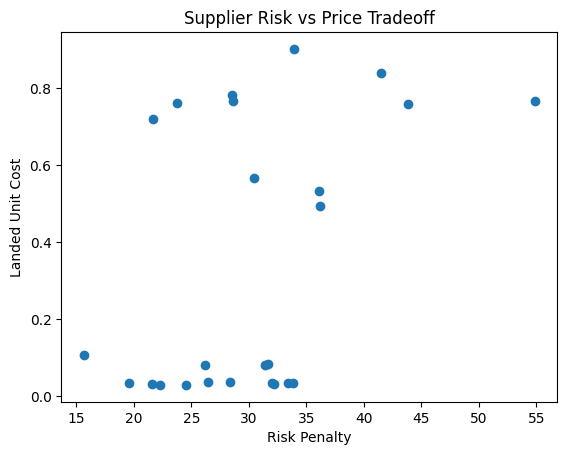

In [23]:
import matplotlib.pyplot as plt

plt.scatter(
    ranked['RiskPenalty'],
    ranked['LandedUnitCost'],
)

plt.xlabel('Risk Penalty')
plt.ylabel('Landed Unit Cost')
plt.title('Supplier Risk vs Price Tradeoff')
plt.show()

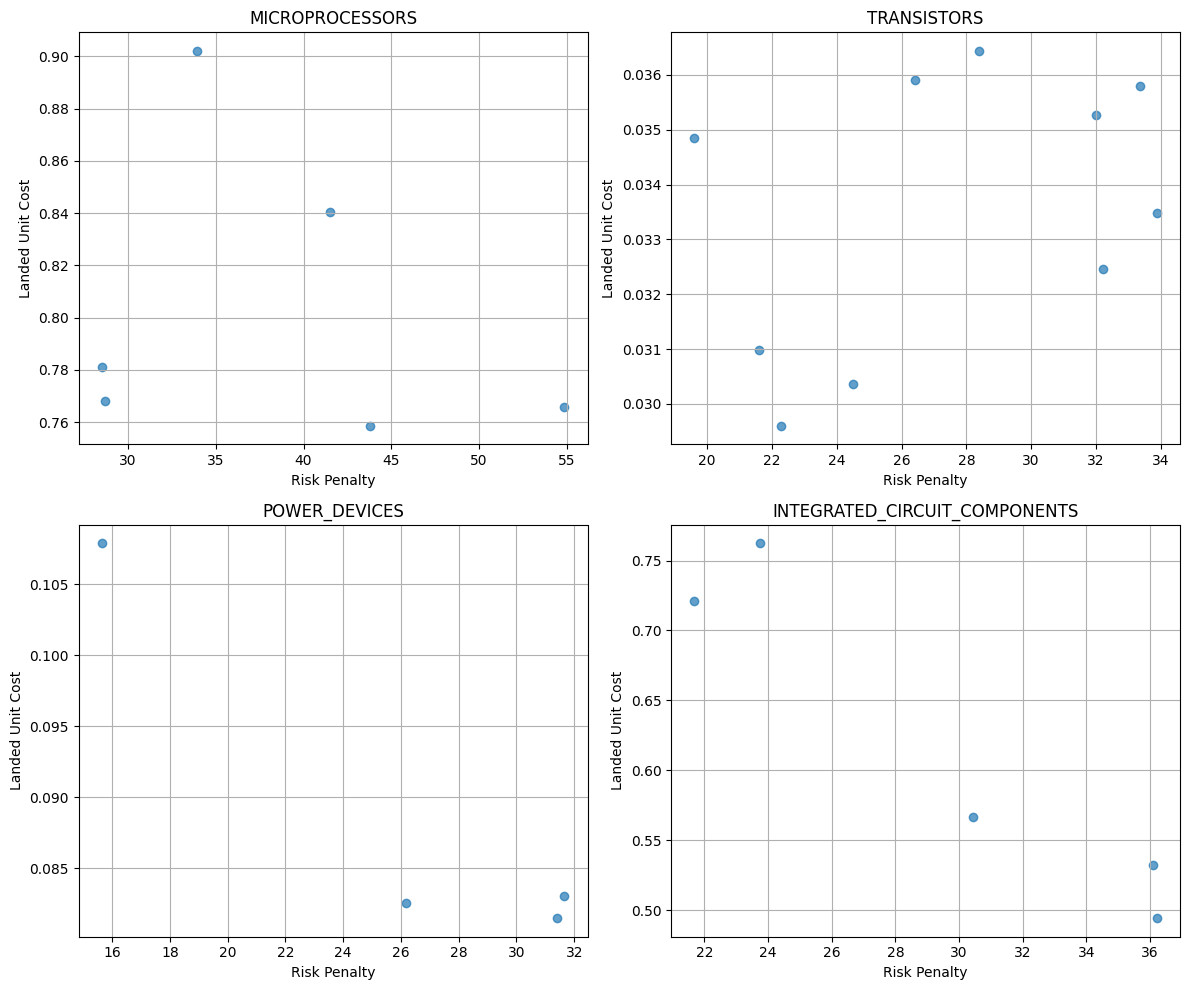

In [ ]:
products = ranked['Product'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for i, product in enumerate(products):
    subset = ranked[ranked["Product"]== product]

    axes[i].scatter(
        subset['RiskPenalty'],
        subset['LandedUnitCost'],
        alpha=0.7
    )

    axes[i].set_title(product.upper())
    axes[i].set_xlabel('Risk Penalty')
    axes[i].set_ylabel('Landed Unit Cost')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# other than transistors, the risk penalty vs landed cost tradeoff looks like what youd expect - as risk penalty increases, so does landed cost, but with some variance as some suppliers are able to offer better prices despite higher risk (or vice versa)